# My Notes

- **Course**: Qubits, entanglement and matrix product sates
- **Author**: Théo HUET
- **Date**: 30/01/2026 - 30/01/2026

# TD2 - Matrix Product State

## Exercice 3 : SVD truncation / MPS intution



In [15]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import constants
from utils import *

In [16]:
N = 200

A = random_complexe_matrix(N,N) # random matrix de taille NxN
A = normalisation(A) # normalisation de la matrice

print("||A||² =", norm2(A).round(2))
print("Trace(AA^{dagger}) =", trace(A @ np.transpose(np.conjugate(A))).round(2).real)


||A||² = 1.0
Trace(AA^{dagger}) = 1.0


We have indeed generated a complex matrix $A$ that represents a normalized state because $||A||^2 = 1$.

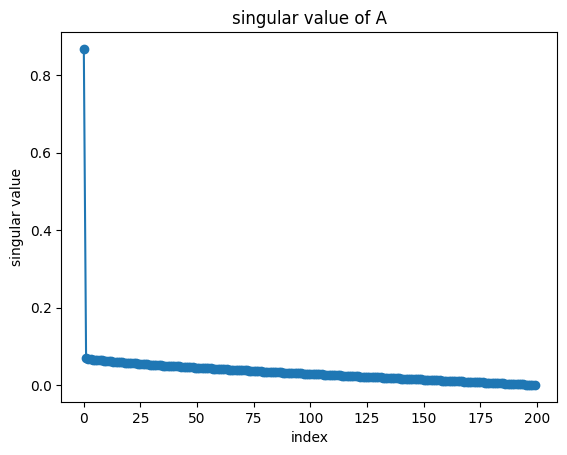

sum singular_value² = 1.0


In [17]:
U, s, Vh = svd(A)

# note : s = si = scipy.linalg.svdvals(A) # calcul les singular value

plt.figure()
plt.plot(s, 'o-')
plt.title("singular value of A")
plt.xlabel("index")
plt.ylabel("singular value")
plt.show()

print("sum singular_value² =", np.sum(s**2).round(2))

We can clearly see that the singular values of our matrix $A$ decrease very quickly to $0$.

We will therefore set a “threshold”: $ds = 0.01$ such that any singular value below this threshold will be removed.

We just need to check whether you are keeping your: $\Sigma_{i}s_i^2 = 1$

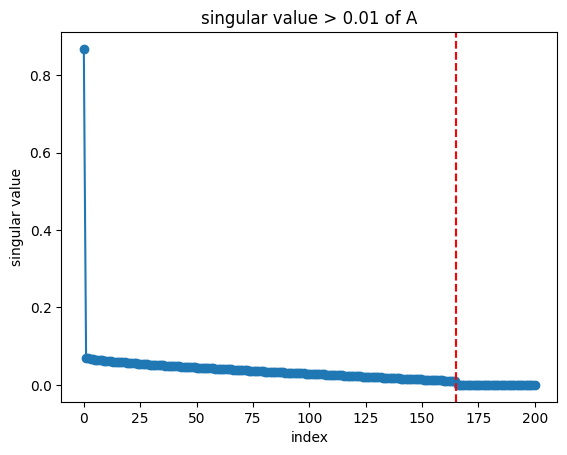

sum singular_value > 0.01)² = 1.0


In [18]:
ds = 0.01

sp = s * (s>ds) # on garde seulement les si > 0.01

i = np.argmin(sp) # pour savoir ou l'on retire des singular values graphiquement
x = np.linspace(0,N,N)

plt.figure()
plt.plot(x, sp, 'o-')
plt.axvline(x=i,color='red',linestyle='--')
plt.title(f"singular value > {ds} of A")
plt.xlabel("index")
plt.ylabel("singular value")
plt.show()
print(f"sum singular_value > {ds})² =", np.sum(sp**2).round(2))

We can see that even if we remove the values below our ‘threshold’ (to the right of the red line), this changes very little in terms of our problem, because we still have: $\Sigma_{s_i>0.1}s_i^2 \approx 1$.

In [19]:
Ap = dot((U * sp), Vh)

print("||A - Ap|| =", (np.linalg.norm(A - Ap)/N).round(5), "<", ds)
print("||A - Ap||² =", (norm2(A - Ap)).round(5), f"= sum (singular_value > {ds})² =", (np.sum((s * (s<ds))**2)).round(5))

||A - Ap|| = 0.00017 < 0.01
||A - Ap||² = 0.00112 = sum (singular_value > 0.01)² = 0.00112


The method is very stable, we have $\frac{||A-A'||}{N} < 0.01$.

Here $\frac{||A-A'||}{N} \approx 0.0002$.

And we have $||A-A'||^2 \approx \Sigma_{s_i<0.1}s_i^2$.

This shows us that our change does not alter the problem, but greatly simplifies it. We will use this later.

## Exercice 4 : 2-Qubit Heisenberg ground state as an MPS

The anti-ferromagnetic Hamiltonian of Two Qubits :
$H = J(\sigma_1^x \sigma_2^x + \sigma_1^y \sigma_2^y + \sigma_1^z \sigma_2^z) = J \vec\sigma_1.\vec\sigma_2 \quad$ and $\quad J = 1$

In [20]:
def compute_H(J : float, nbr_qubit : int) :
  if nbr_qubit == 2 :
    return J*(np.kron(constants.X, constants.X) + np.kron(constants.Y, constants.Y) + np.kron(constants.Z, constants.Z))
  elif nbr_qubit == 3 :
    return J*(np.kron(np.kron(constants.X, constants.X),constants.I) + np.kron(np.kron(constants.Y, constants.Y),constants.I) + np.kron(np.kron(constants.Z, constants.Z),constants.I)) + J*(np.kron(np.kron(constants.I, constants.X),constants.X) + np.kron(np.kron(constants.I, constants.Y),constants.Y) + np.kron(np.kron(constants.I, constants.Z),constants.Z))

In [28]:
J = 1.
nbr_qubit = 2

H = compute_H(J, nbr_qubit)

E0, v0 = ground_state(H)

print("E0 =", E0)
print("v0 = ", v0.real.round(3), "\nwith 1/sqrt(2) =", (1/np.sqrt(2)).round(3))

E0 = -3.0
v0 =  [ 0.     0.707 -0.707  0.   ] 
with 1/sqrt(2) = 0.707


Ground state :

$E_0 = -3\quad$ and $\quad v_0 = \frac{|01> -|10>}{\sqrt2}$.

Because $v_0 = (0 \quad \frac{1}{\sqrt2} \quad -\frac{1}{\sqrt2} \quad 0) $ in the base $|00>, |01>, |10>, |11>$.

In [22]:
vM = v0.reshape((2,2))

U, s, Vh = svd(vM)

print("U =\n", U)
print("s =\n", s)
print("Vh =\n", Vh)

U =
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
s =
 [0.70710678 0.70710678]
Vh =
 [[-1.+0.j -0.+0.j]
 [ 0.+0.j  1.+0.j]]


### Output 1

In [23]:
A, B = U, s*Vh

norm = mps_norm(A, B)

c = np.einsum('sk,kS,sm,Sn,ml,ln->', A, B, constants.SP,constants.SM, A.conj(), B.conj())

print("Output 1 :")
print("norm =", norm.round(2))
print("c+- =",c.round(2).real, "= -1/2")

Output 1 :
norm = 1.0
c+- = -0.5 = -1/2


The anti-ferromagnetic Hamiltonian of **Three Qubits** :

$H = J \vec\sigma_1.\vec\sigma_2 + J \vec\sigma_2.\vec\sigma_3 \quad$ and $\quad J = 1$

In [24]:
J = 1
nbr_qubit = 3

H = compute_H(J, nbr_qubit)

E0, v0 = ground_state(H)

vR = v0.reshape((2,4))

# first SVD
U, s, Vh = svd(vR)

A = U

# second SVD
Up, sp, Vhp = svd(s*Vh.reshape((4,2)))

B, C = Up, sp*Vhp

In [25]:
print("A :\n", A)
print("B :\n", B)
print("C :\n", C)

norm = np.einsum('sm,ml,lk,si,ij,jk->',A.conj(), B.conj(), C.conj(), A, B, C) # verification
print(norm)

A :
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
B :
 [[ 0.00000000e+00+0.j  1.00000000e+00+0.j]
 [-6.66666667e-01+0.j  0.00000000e+00+0.j]
 [ 7.45355992e-01+0.j  2.22044605e-16+0.j]
 [ 8.27511384e-17+0.j  2.46519033e-32+0.j]]
C :
 [[-1.22474487+0.j -0.        +0.j]
 [-0.        +0.j -0.18257419+0.j]]


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (2,2)->(2,2) (4,2)->(2,4,newaxis) (2,2)->(2,2,newaxis,newaxis) (2,2)->(2,newaxis,newaxis,newaxis,newaxis,2) (4,2)->(4,2,newaxis,newaxis,newaxis,newaxis) (2,2)->(2,2,newaxis,newaxis,newaxis) 

### Output 2

In [ ]:
c = np.einsum('ij,jk,kl,iS,lm,Ss,mn,sn->',A,B,C,constants.SP,constants.SM,A.conj(),C.conj(),B.conj())
print(c)

need to be $\approx 0.1666\dots$